# Introduction
## Help

# Initial Questions
1. What do we want to know about airline on-time performance?
2. How will the answer be useful in decision making?

# Data Specific Questions
**1. How does on-time performance vary across carrier, airports, time, day, maybe aircraft?**
   
    -  What's the overall distribution of any flight delays? 
    -  What airline has the best and worst on-time performance? 
    -  How do routes (short/long) correlate with performance? 
    -  What departure time windows have the least amount of delays? Most amount of delays? 
    -  What is the average delay per airport? per airline? per airport & airline? 
    - What percentage of flights leave on-time? Delayed? 
    -  What time ranges have the highest/lowest delays? 
    -How many flights per day? 
        - By airport? By carrier? 
    -What is the average aircraft turnaround time by carrier? (I'd think we'd have to subtract any weather, security, or NAS delays because those are not impacted their ability to get the aircraft ready for the next flight) 
    

**2. What delay propagation patterns can we draw?**

    - Is there recovery or do they compound / propagate? 
            - Are some airlines better at recovering than others? 
        - What information can we draw from taxi times? Thinking about traffic jams at the runways due to built up delays
    - What percent of flights are delayed 15, 30, 60+ minutes? 
    - What is the % chance that a late arrival will cause the next flight to also be late 
    - What is the average total time per day in delays a carrier has? 
    - What correlations are there between delays and cancelations (mainly downstream, think about how a major storm could cause mass cancellations in a short period of time)? 

**3. What factors have the greatest effect on on-time performance**
   
    - Weather 
        - What is the average number of delays per day due to weather?
        - What percentage of days are due to weather?
        - Which airports have the highest/most frequent weather delays?
        - How much time is the average weather delay?
    - Secuirty 
        - What percentage of delays are due to security issues?
        - How much time is the average security delay? 
    - Carrier 
        - Which carriers have the highest delays?
        - How much time is the average carrier delay
    - National Aviation System (Delay within control of ATC, not airline) 
        - Which airports have the most/highest delays due to NAS?
        - How much time is the average NAS delau
        - What is the total number 

4. What is the overall cost of delays?
    -Fuel, labor, etc. 

6. What is the impact to customers?
    - Which airports should customers expect delays
    - What percent of flights are delayed 15, 30, 60+ minutes?


## Brandon Analysis Questions
    -  How do routes correlate with performance? 
    - What are the max, min, and average flight times? Is there a relationships to flight length and delays
    -  What departure time windows have the least amount of delays? Most amount of delays? 
    -  What time ranges have the highest/lowest delays? 
    -How many flights per day? 
        - By airport? By carrier? 
    - How resilient is each carrier to delay shocks?
        - What % of flights recover to on-time after a delay?
    - What is the % chance that a late arrival will cause the next flight to also be late T
    - What is the average total time per day in delays a carrier has? 
    - Weather 
        - What is the average number of delays per day due to weather?
        - What percentage of days are due to weather?
        - Which airports have the highest/most frequent weather delays?
        - How much time is the average weather delay?
    - Secuirty 
        - What percentage of delays are due to security issues?
        - How much time is the average security delay? 
    - Are taxi times leading indicators of airport congestion?
        - What is the relationship between taxi out times and departure delays (Wheels off)
    
## Trace Analysis Questions
    -  What's the overall distribution of any flight delays? 
    - What airports have the highest delays?
    -  What airline has the best and worst on-time performance? 
    -  What is the average delay per airport? per airline? per airport & airline? 
    - What percentage of flights leave on-time? Delayed? 
    -What is the average aircraft turnaround time by carrier? (I'd think we'd have to subtract any weather, security, or NAS delays because those are not impacted their ability to get the aircraft ready for the next flight) 
    - What percent of flights are delayed 15, 30, 60+ minutes? 
    - What is the % chance that a late arrival will cause the next flight to also be late 
    - What correlations are there between delays and cancelations (mainly downstream, think about how a major storm could cause mass cancellations in a short period of time)? 
    - Carrier 
        - Which carriers have the highest delays?
        - How much time is the average carrier delay
    - National Aviation System (Delay within control of ATC, not airline) 
        - Which airports have the most/highest delays due to NAS?
        - How much time is the average NAS delay?
    - What is the likelyhood of a delay based on airline, airport, and time of day?
    - What aircraft have the highest carrier delays?
    - What day of the week has the highest delays?

## Amibtion
- What is the cost to airlines due to delays? Per day? Per Year?
- 


        
# Source Data
United States Department of Transportation - U.S. Buerau of Transportation Statistics

# Features Needed
### 1. Date

### 2. Time of Day

### 3. Carrier
- American
- United
- Delta
- Southwest
- Alaska
- JetBlue
- Spirit
- Frontier

### 5. Airport (Departure)
- Dallas Fort-Worth (DFW) **1**
- Atlanta (ATL)           **2**
- Los Angeles (LAX)       **3**
- New York                **6**
  - JFK
- Miami (MIA)             **8**
- Chicago O'Hare (OHD)    **4**
- Phoenix (PHX)           **7**
- Denver (DEN)            **5**
- San Franscisco (SFO)
- Washington D.C.
  - Dulles (IAD)

**I was thinking we could just narrow it down to 5-10 airports but since we have the airport IDs in the data, I don't entirely see the benefit of just picking 10 other than maybe lessening the complexity or size of the data. Maybe we could just do some groupings by U.S. region? Open to suggestions**


### 7. Airport (Arrival) / Destination

### 8. Reason For Delay
- Weather
- Carrier
- Security
- Late Aircraft
- National Aviation System (NAS)

**we can leave these split up into their own feature**

### 9. Tail Number

### 10. Elapsed Time

### 11. State

### 12. Wheels Up

### 13. Wheel Down

### 14. Taxi Time (We could create a column that sums up taxi out and taxi in. However, taxi out could be an important variable for assessing NAS delays)




# 1. Initial Load & Reconniassance 
## Questions to Answer
1. Tidy or not?
2. Entities, Attributes, Observations?
3. Variable Types?
4. Shape & scale?
5. Any obvious problems?

**I will add a table of feature names and a brief description for each so it's easy to follow the table**

### Hypothessis
- Relationships worth exploring
    - Numeric
    - Categorical
    - Numeric vs Categorical
    - Numeric vs Numeric 
    -  on-time performance vs. time of day
    -  on-time performance vs carrier
    -  on-time performance vs airport
    -  Carrier vs % of flights delayed
    -  Carrier vs departure / arrival delays

- 


#### Preprocessing Note
Data are in individual CSV files within compressed directories separated by year and month.  Run `python ~/data/bts_preprocess.py` to generate the pickle file used in this notebook

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [146]:
df = pd.read_parquet("../data/bts_all.parquet")

In [147]:
df.tail()

,FlightDate,Reporting_Airline,Tail_Number,Origin,Dest,CRSDepTime,DepDelay,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,Distance,CarrierDelay,WeatherDelay,NASDelay
35417935,2025-07-18,NK,N679NK,EWR,RDU,1559,-7.0,11.0,1603.0,1709.0,8.0,1740,-23.0,416.0,NaN,NaN,NaN
35417936,2025-07-19,NK,N664NK,EWR,RDU,1600,-4.0,63.0,1659.0,1827.0,8.0,1741,54.0,416.0,0.0,0.0,54.0
35417937,2025-07-20,NK,N664NK,EWR,RDU,1559,-6.0,27.0,1620.0,1742.0,9.0,1740,11.0,416.0,NaN,NaN,NaN
35417938,2025-07-21,NK,N664NK,EWR,RDU,1559,16.0,14.0,1629.0,1735.0,8.0,1740,3.0,416.0,NaN,NaN,NaN
35417939,2025-07-24,NK,N671NK,EWR,RDU,1559,-7.0,13.0,1605.0,1709.0,9.0,1740,-22.0,416.0,NaN,NaN,NaN


In [148]:
df_aircraft = pd.read_csv("../data/Raw/Aircraft.csv")
df_aircraft

,N-NUMBER,MFR MDL CODE,MFR,MODEL,NO-SEATS
0,100,7100510,PIPER,J3C-65,2
1,10000,2130004,CIRRUS DESIGN CORP,SR22T,5
2,10001,9601202,WACO,ASO,3
3,10004,2072738,CESSNA,T182T,4
4,10006,1152020,BEECH,D-45 (T-34B),4
...,...,...,...,...,...
308193,9ZS,5760102,MOLINO OY,PIK-20E,1
308194,9ZT,2130001,CIRRUS DESIGN CORP,SR22,4
308195,9ZU,7101828,PIPER,PA-18-150,2
308196,9ZV,1181511,BELL,206B,5


In [149]:

#Changing feature names for aircraft DF
mod_aircraft = df_aircraft.rename(columns= {
    'N-NUMBER': 'Tail_Number',
    'MFR': 'Manufacturer',
    'NO-SEATS': 'Number_of_Seats'
})
mod_aircraft

df_merged = df.merge(mod_aircraft, on='Tail_Number', how='left')
df_merged

,FlightDate,Reporting_Airline,Tail_Number,Origin,Dest,CRSDepTime,DepDelay,TaxiOut,WheelsOff,WheelsOn,...,CRSArrTime,ArrDelay,Distance,CarrierDelay,WeatherDelay,NASDelay,MFR MDL CODE,Manufacturer,MODEL,Number_of_Seats
0,2020-01-17,B6,N661JB,PBI,BDL,1940,-14.0,15.0,1941.0,2212.0,...,2229,-11.0,1133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-18,B6,N584JB,PBI,BDL,1940,-14.0,14.0,1940.0,2207.0,...,2229,-9.0,1133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-19,B6,N662JB,PBI,BDL,1940,7.0,11.0,1958.0,2217.0,...,2229,-6.0,1133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-20,B6,N784JB,PBI,BDL,1940,-7.0,27.0,2000.0,2220.0,...,2229,4.0,1133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-21,B6,N784JB,PBI,BDL,1940,12.0,10.0,2002.0,2229.0,...,2229,6.0,1133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35417935,2025-07-18,NK,N679NK,EWR,RDU,1559,-7.0,11.0,1603.0,1709.0,...,1740,-23.0,416.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35417936,2025-07-19,NK,N664NK,EWR,RDU,1600,-4.0,63.0,1659.0,1827.0,...,1741,54.0,416.0,0.0,0.0,54.0,NaN,NaN,NaN,NaN
35417937,2025-07-20,NK,N664NK,EWR,RDU,1559,-6.0,27.0,1620.0,1742.0,...,1740,11.0,416.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35417938,2025-07-21,NK,N664NK,EWR,RDU,1559,16.0,14.0,1629.0,1735.0,...,1740,3.0,416.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [150]:
df_merged

,FlightDate,Reporting_Airline,Tail_Number,Origin,Dest,CRSDepTime,DepDelay,TaxiOut,WheelsOff,WheelsOn,...,CRSArrTime,ArrDelay,Distance,CarrierDelay,WeatherDelay,NASDelay,MFR MDL CODE,Manufacturer,MODEL,Number_of_Seats
0,2020-01-17,B6,N661JB,PBI,BDL,1940,-14.0,15.0,1941.0,2212.0,...,2229,-11.0,1133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-18,B6,N584JB,PBI,BDL,1940,-14.0,14.0,1940.0,2207.0,...,2229,-9.0,1133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-19,B6,N662JB,PBI,BDL,1940,7.0,11.0,1958.0,2217.0,...,2229,-6.0,1133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-20,B6,N784JB,PBI,BDL,1940,-7.0,27.0,2000.0,2220.0,...,2229,4.0,1133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-21,B6,N784JB,PBI,BDL,1940,12.0,10.0,2002.0,2229.0,...,2229,6.0,1133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35417935,2025-07-18,NK,N679NK,EWR,RDU,1559,-7.0,11.0,1603.0,1709.0,...,1740,-23.0,416.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35417936,2025-07-19,NK,N664NK,EWR,RDU,1600,-4.0,63.0,1659.0,1827.0,...,1741,54.0,416.0,0.0,0.0,54.0,NaN,NaN,NaN,NaN
35417937,2025-07-20,NK,N664NK,EWR,RDU,1559,-6.0,27.0,1620.0,1742.0,...,1740,11.0,416.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35417938,2025-07-21,NK,N664NK,EWR,RDU,1559,16.0,14.0,1629.0,1735.0,...,1740,3.0,416.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### How do routes correlate with delays?
We're looking to assess how delays vary by route. In this context, we'll define a route as a departure/arrival airport pair.  We are interested in identifying the routes with the highest average delay per flight. 

In [151]:
#create a route column from origin and destination columns
df["route"] = df["Origin"] + "_" + df["Dest"]

#build a dataframe of flight delay information for each route
route_delay = (
    df.groupby("route")
      .agg(total_arr_delay=("ArrDelay", "sum"),
           n_flights=("ArrDelay", "count"))
      .sort_values("n_flights", ascending=False)
)


In [152]:
route_delay['avg_delay_per_flight'] = route_delay['total_arr_delay'] / route_delay['n_flights']
route_delay.head()

,total_arr_delay,n_flights,avg_delay_per_flight
route,,,
SFO_LAX,45553.0,57994,0.785478
LAX_SFO,219110.0,57986,3.778671
HNL_OGG,155183.0,54825,2.830515
OGG_HNL,164415.0,54742,3.003453
LAX_LAS,340885.0,50807,6.709410


#### Establish a minimum number of flights
To avoid the results being skewed by routes with very few flights, we'll establish a minimum threshold of number of flights in order for a route to be considered in the analysis. To do this, we'll start with a cutoff that includes 80% of all flights and adjust as necessary.

In [153]:
# Compute the cumulative percentage of total flights as routes are sorted by descending flight count
route_delay["cumulative_share"] = route_delay["n_flights"].cumsum() / route_delay["n_flights"].sum()
route_delay

,total_arr_delay,n_flights,avg_delay_per_flight,cumulative_share
route,,,,
SFO_LAX,45553.0,57994,0.785478,0.001680
LAX_SFO,219110.0,57986,3.778671,0.003360
HNL_OGG,155183.0,54825,2.830515,0.004948
OGG_HNL,164415.0,54742,3.003453,0.006534
LAX_LAS,340885.0,50807,6.709410,0.008006
...,...,...,...,...
MEM_DSM,0.0,0,NaN,1.000000
PSC_GEG,0.0,0,NaN,1.000000
MDW_DSM,0.0,0,NaN,1.000000


In [154]:
#Establish 80% cutoff mark
cutoff_row = route_delay[route_delay["cumulative_share"] >= 0.80].iloc[0]
cutoff_value = cutoff_row["n_flights"]
cutoff_value


np.float64(4669.0)

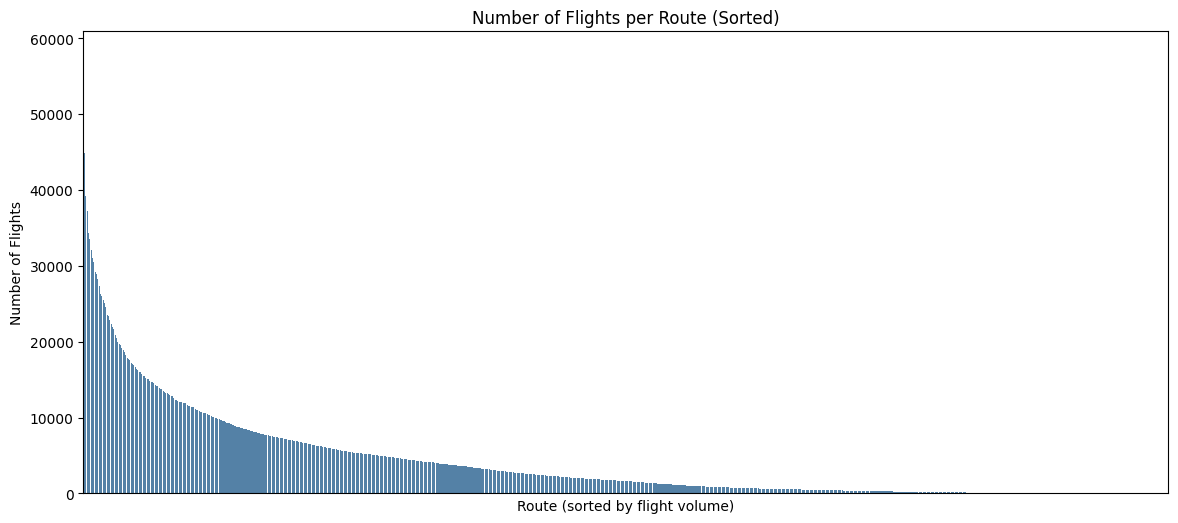

In [155]:
plt.figure(figsize=(14,6))
sns.barplot(
    data=route_delay.sort_values("n_flights", ascending=False),
    x=route_delay.sort_values("n_flights", ascending=False).index,
    y="n_flights",
    color="steelblue"
)
plt.title("Number of Flights per Route (Sorted)")
plt.xlabel("Route (sorted by flight volume)")
plt.ylabel("Number of Flights")
plt.xticks([], [])   #hide x-axis labels
plt.show()

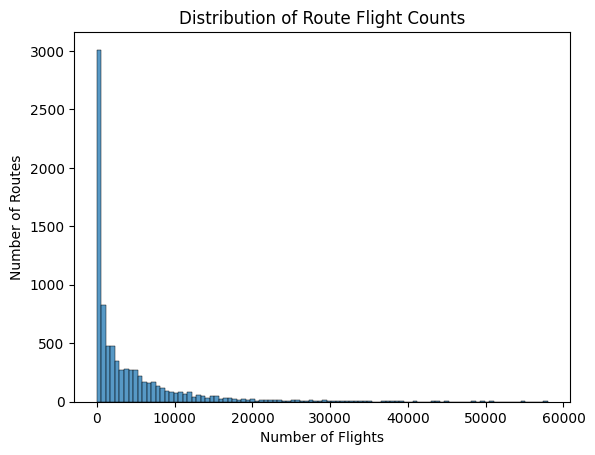

In [156]:
sns.histplot(route_delay["n_flights"], bins=100)
plt.title("Distribution of Route Flight Counts")
plt.xlabel("Number of Flights")
plt.ylabel("Number of Routes")
plt.show()


Given the above histogram and bar char, there is a long tail of lower-volume routes that might be of interest.  Let's up the threshold to 95% of flights.

In [157]:
#Establish 95% cutoff mark
cutoff_row = route_delay[route_delay["cumulative_share"] >= 0.95].iloc[0]
cutoff_value = cutoff_row["n_flights"]
cutoff_value

np.float64(1623.0)

A minimum threshold of 1623 flights for a route covers 95% of all flights. Now, we'll find the average delay time per flight for all routes with 1623 flights or more.

In [158]:
min_flights = 1623


filtered_routes = route_delay[route_delay["n_flights"] >= min_flights]

# Sort by highest avg delay per flight
filtered_routes = filtered_routes.sort_values(
    "avg_delay_per_flight",
    ascending=False
)
filtered_routes.drop(columns=["cumulative_share"], inplace=True) # cumulative share doesn't make sense in this context



In [159]:
worst_routes = filtered_routes.head()
worst_routes

,total_arr_delay,n_flights,avg_delay_per_flight
route,,,
BDL_SJU,123084.0,4093,30.071830
SJU_DCA,48053.0,1773,27.102651
ASE_DFW,136929.0,5143,26.624344
DFW_MDT,49188.0,1872,26.275641
EYW_PHL,58381.0,2225,26.238652


In [160]:
best_routes = filtered_routes.tail()
best_routes

,total_arr_delay,n_flights,avg_delay_per_flight
route,,,
BTM_SLC,-25150.0,3319,-7.577584
KOA_OAK,-13140.0,1733,-7.582227
RHI_MSP,-34324.0,4123,-8.325006
TYS_DTW,-27141.0,3211,-8.452507
LIH_DEN,-17071.0,1685,-10.131157


Based on this analysis, there is no standout commonality among the best and worst routes for delays or early arrivals.  Let's explore volume per day at the airports in the top 5 and bottom 5 in the delay data to see if there is a signal there.

In [161]:
top_worst_airports = ["BDL", "SJU", "DCA", "ASE", "DFW", "MDT", "EYW", "PHL"]
top_best_airports  = ["BTM", "SLC", "KOA", "OAK", "RHI", "MSP", "TYS", "DTW", "LIH", "DEN"]

airport_daily_volume = (
    df.melt(
        id_vars=["FlightDate"],
        value_vars=["Origin", "Dest"],
        var_name="type",
        value_name="airport"
    )
    .groupby(["airport", "FlightDate"])
    .size()
    .reset_index(name="flights_per_day")
)


In [162]:
# Average volume / day at the airports in the worst routes
worst_filtered = (
    airport_daily_volume[airport_daily_volume["airport"].isin(top_worst_airports)]
)
worst_filtered_avg = worst_filtered.groupby("airport")["flights_per_day"].mean()

In [163]:
# Average volume / day at the airports in the best routes
best_filtered = (
    airport_daily_volume[airport_daily_volume["airport"].isin(top_best_airports)]
)
best_filtered_avg = best_filtered.groupby("airport")["flights_per_day"].mean()

In [164]:
def create_route_volume_df(route_df,filtered_avg):
    """
    Given a dataframe of routes and a series of averages,
    create a dataframe of routes with volume totals and differences
    """
    rows = []
    for route in route_df.index:
        origin,dest = route.split("_")
        volume_diff = filtered_avg[origin] - filtered_avg[dest]
        total_volume = filtered_avg[origin] + filtered_avg[dest]
        rows.append({
            "route": route,
            "origin": origin,
            "dest": dest,
            "volume_diff": volume_diff,
            "total_volume": total_volume
        })
    
    return pd.DataFrame(rows).set_index("route")


    
    

In [165]:
best_route_volumes_df = create_route_volume_df(best_routes,best_filtered_avg)
best_route_volumes_df

,origin,dest,volume_diff,total_volume
route,,,,
BTM_SLC,BTM,SLC,-596.605199,603.881314
KOA_OAK,KOA,OAK,-137.709171,298.629230
RHI_MSP,RHI,MSP,-639.181952,647.837175
TYS_DTW,TYS,DTW,-607.741540,751.308975
LIH_DEN,LIH,DEN,-1410.480137,1557.292300


In [166]:
worst_route_volumes_df = create_route_volume_df(worst_routes,worst_filtered_avg)
worst_route_volumes_df

,origin,dest,volume_diff,total_volume
route,,,,
BDL_SJU,BDL,SJU,-51.698872,281.899951
SJU_DCA,SJU,DCA,-474.128004,807.726827
ASE_DFW,ASE,DFW,-1499.455398,1574.295460
DFW_MDT,DFW,MDT,1509.433055,1564.317803
EYW_PHL,EYW,PHL,-436.418833,521.755763


In [167]:
#Best vs Worst Average Total Volumes
print("Best Route Total Volume:",best_route_volumes_df['total_volume'].mean())
print("Worst Route Total Volume:",worst_route_volumes_df['total_volume'].mean())

Best Route Total Volume: 771.7897989210397
Worst Route Total Volume: 949.9991606193283


In [168]:
#Best vs Worst Average Volume Difference
print("Best Route Volume Diff:",best_route_volumes_df['volume_diff'].mean())
print("Worst Route Volume Diff:",worst_route_volumes_df['volume_diff'].mean())

Best Route Volume Diff: -678.3435998038254
Worst Route Volume Diff: -190.45361034683157


There is signal in both the difference and totals in volumes between an origin and destination for more exploration. Next, we'll do a regression of these two variables on the entire set.

In [169]:
avg_daily_volume = airport_daily_volume.groupby("airport")["flights_per_day"].mean()
route_volume_df = create_route_volume_df(route_delay,avg_daily_volume)

In [170]:
merged_route_volumes = route_volume_df.merge(route_delay,on="route")

In [171]:
merged_route_volumes = merged_route_volumes[merged_route_volumes["n_flights"] >= min_flights]
merged_route_volumes.head()

,origin,dest,volume_diff,total_volume,total_arr_delay,n_flights,avg_delay_per_flight,cumulative_share
route,,,,,,,,
SFO_LAX,SFO,LAX,-310.902403,1629.554684,45553.0,57994,0.785478,0.001680
LAX_SFO,LAX,SFO,310.902403,1629.554684,219110.0,57986,3.778671,0.003360
HNL_OGG,HNL,OGG,147.317803,425.764100,155183.0,54825,2.830515,0.004948
OGG_HNL,OGG,HNL,-147.317803,425.764100,164415.0,54742,3.003453,0.006534
LAX_LAS,LAX,LAS,68.305542,1872.151545,340885.0,50807,6.709410,0.008006


In [172]:
#Single Variate Regression for volume difference
X = merged_route_volumes[["volume_diff"]] #predictor
y = merged_route_volumes["avg_delay_per_flight"] #predictand

X = sm.add_constant(X) #Intercept

# Fit model
model = sm.OLS(y, X).fit()

print(model.summary())


                             OLS Regression Results                             
Dep. Variable:     avg_delay_per_flight   R-squared:                       0.003
Model:                              OLS   Adj. R-squared:                  0.003
Method:                   Least Squares   F-statistic:                     12.73
Date:                  Fri, 05 Dec 2025   Prob (F-statistic):           0.000363
Time:                          15:17:27   Log-Likelihood:                -12562.
No. Observations:                  4204   AIC:                         2.513e+04
Df Residuals:                      4202   BIC:                         2.514e+04
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           4.7492      0.

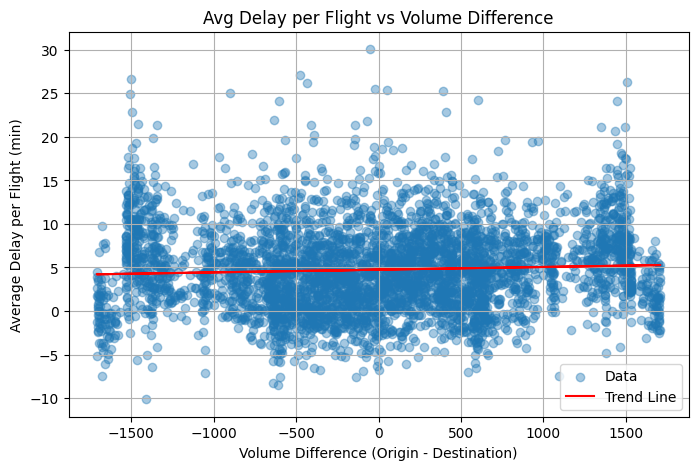

In [173]:
#Plot Avg Delay per FLight vs Volume Difference

x = merged_route_volumes["volume_diff"]
y = merged_route_volumes["avg_delay_per_flight"]

# Fit linear trend
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.4, label="Data")
plt.plot(x, m*x + b, color="red", label="Trend Line")

plt.xlabel("Volume Difference (Origin - Destination)")
plt.ylabel("Average Delay per Flight (min)")
plt.title("Avg Delay per Flight vs Volume Difference")
plt.legend()
plt.grid(True)
plt.show()


In [174]:
#Single Variate Regression for total volume
X = merged_route_volumes[["total_volume"]] #predictor
y = merged_route_volumes["avg_delay_per_flight"] #predictand

X = sm.add_constant(X) #Intercept

# Fit model
model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     avg_delay_per_flight   R-squared:                       0.018
Model:                              OLS   Adj. R-squared:                  0.018
Method:                   Least Squares   F-statistic:                     76.79
Date:                  Fri, 05 Dec 2025   Prob (F-statistic):           2.72e-18
Time:                          15:17:27   Log-Likelihood:                -12530.
No. Observations:                  4204   AIC:                         2.506e+04
Df Residuals:                      4202   BIC:                         2.508e+04
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            3.3693     

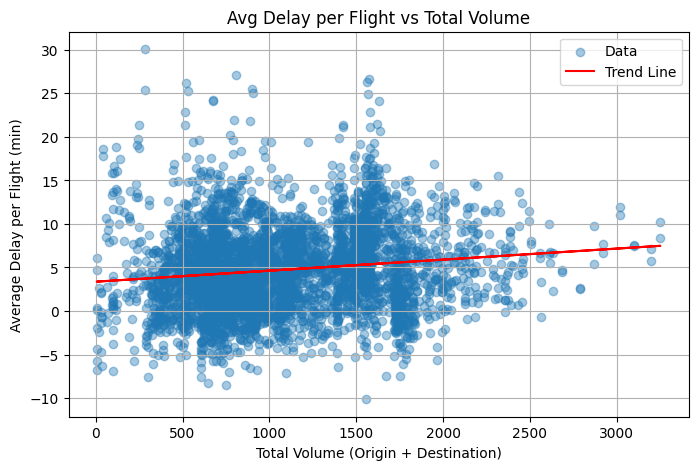

In [175]:
#Plot Avg Delay per FLight vs Total Volume

x = merged_route_volumes["total_volume"]
y = merged_route_volumes["avg_delay_per_flight"]

# Fit linear trend
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.4, label="Data")
plt.plot(x, m*x + b, color="red", label="Trend Line")

plt.xlabel("Total Volume (Origin + Destination)")
plt.ylabel("Average Delay per Flight (min)")
plt.title("Avg Delay per Flight vs Total Volume")
plt.legend()
plt.grid(True)
plt.show()


The total volume of both origin and destination is slightly better predictor of average delay (1.8% contribution to variance based on R-squared) than the volume difference (~0.3% contribution) but both are tiny.  Next, we'll explore the relationship between flight distance and average delay.

### How do flight lengths correlate with delays?

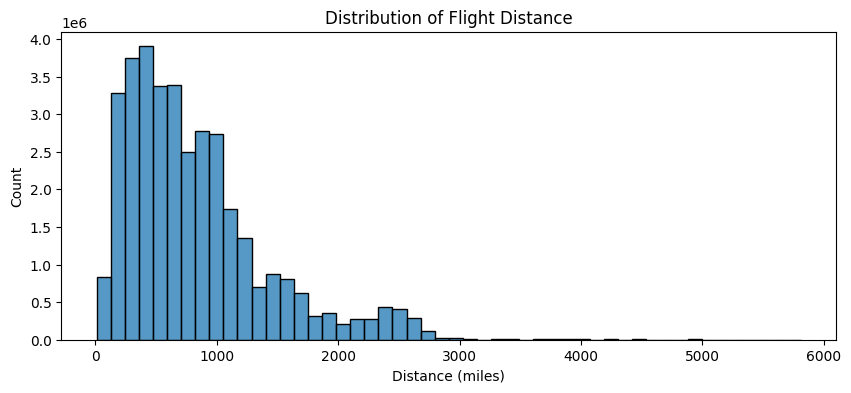

In [176]:
# Initial Histogram of distances
plt.figure(figsize=(10,4))
sns.histplot(df["Distance"], bins=50)
plt.title("Distribution of Flight Distance")
plt.xlabel("Distance (miles)")
plt.show()

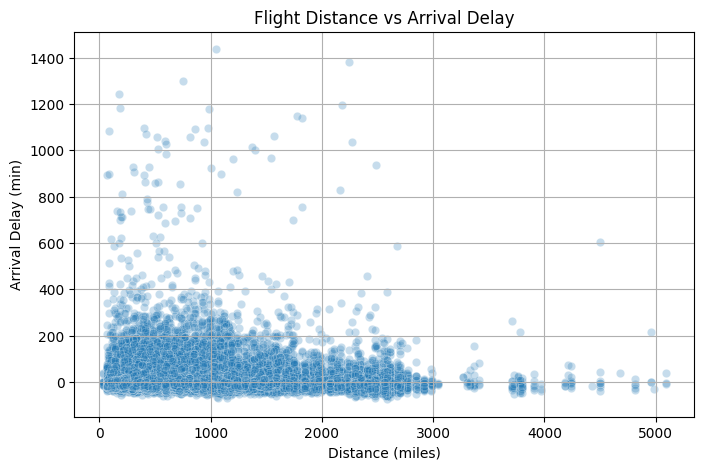

In [177]:
#Random sampling of flight distances vs delays
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df.sample(50000, random_state=42),  
    x="Distance",
    y="ArrDelay",
    alpha=0.25
)
plt.title("Flight Distance vs Arrival Delay")
plt.xlabel("Distance (miles)")
plt.ylabel("Arrival Delay (min)")
plt.grid(True)
plt.show()


Based on the scatter plot, there isn't a linear relationship, but let's check correlation.

In [178]:
corr = df["Distance"].corr(df["ArrDelay"])
corr

np.float64(-0.0008228821260751163)

Correlation (R-squared) is near 0.  As expected, there is almost no relationship between flight delay and length, at least as a predictor.  

In [179]:
dep = df.copy()

# Convert the FlightDate columnn to datetime
dep["FlightDate"] = pd.to_datetime(dep["FlightDate"], errors="coerce")
dep

,FlightDate,Reporting_Airline,Tail_Number,Origin,Dest,CRSDepTime,DepDelay,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,Distance,CarrierDelay,WeatherDelay,NASDelay,route
0,2020-01-17,B6,N661JB,PBI,BDL,1940,-14.0,15.0,1941.0,2212.0,6.0,2229,-11.0,1133.0,NaN,NaN,NaN,PBI_BDL
1,2020-01-18,B6,N584JB,PBI,BDL,1940,-14.0,14.0,1940.0,2207.0,13.0,2229,-9.0,1133.0,NaN,NaN,NaN,PBI_BDL
2,2020-01-19,B6,N662JB,PBI,BDL,1940,7.0,11.0,1958.0,2217.0,6.0,2229,-6.0,1133.0,NaN,NaN,NaN,PBI_BDL
3,2020-01-20,B6,N784JB,PBI,BDL,1940,-7.0,27.0,2000.0,2220.0,13.0,2229,4.0,1133.0,NaN,NaN,NaN,PBI_BDL
4,2020-01-21,B6,N784JB,PBI,BDL,1940,12.0,10.0,2002.0,2229.0,6.0,2229,6.0,1133.0,NaN,NaN,NaN,PBI_BDL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35417935,2025-07-18,NK,N679NK,EWR,RDU,1559,-7.0,11.0,1603.0,1709.0,8.0,1740,-23.0,416.0,NaN,NaN,NaN,EWR_RDU
35417936,2025-07-19,NK,N664NK,EWR,RDU,1600,-4.0,63.0,1659.0,1827.0,8.0,1741,54.0,416.0,0.0,0.0,54.0,EWR_RDU
35417937,2025-07-20,NK,N664NK,EWR,RDU,1559,-6.0,27.0,1620.0,1742.0,9.0,1740,11.0,416.0,NaN,NaN,NaN,EWR_RDU
35417938,2025-07-21,NK,N664NK,EWR,RDU,1559,16.0,14.0,1629.0,1735.0,8.0,1740,3.0,416.0,NaN,NaN,NaN,EWR_RDU


In [180]:
# Turn departure time into a datetime object for better analysis
# This require combining the time information with flight date

# Prep a series of strings to comibe with flight dates
crs_str = (
    dep["CRSDepTime"]
    .astype(str)
    .str.zfill(4)     # "0730", "1745"
)

# Combine FL_DATE + hh:mm into a true datetime
dep["CRSDepDateTime"] = pd.to_datetime(
    dep["FlightDate"].dt.strftime("%Y-%m-%d") + " " +
    crs_str.str.slice(0, 2) + ":" + crs_str.str.slice(2, 4),
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

# Drop any rows where we still failed to build a datetime
dep = dep[dep["CRSDepDateTime"].notna()].copy()

In [181]:
#Check to see how many rows we lost in the operation
rows_lost = len(df.index) - len(dep.index)
rows_lost

2

We'll first examine the hours of day with the highest and lowest average delay to check for a signal worth exploring.

In [182]:
#  Create Hourly Delay Stats

dep["dep_hour"] = dep["CRSDepDateTime"].dt.hour  # 0–23

hourly_dep_delay = (
    dep.groupby("dep_hour")["DepDelay"]
      .agg(
          n_flights="size",
          avg_dep_delay="mean",
          median_dep_delay="median",
          pct_delayed_15=lambda s: (s >= 15).mean(),
          pct_on_time_or_early=lambda s: (s <= 0).mean()
      )
      .reset_index()
      .sort_values("dep_hour")
)

hourly_dep_delay



,dep_hour,n_flights,avg_dep_delay,median_dep_delay,pct_delayed_15,pct_on_time_or_early
0,0,61111,12.717885,-2.0,0.214773,0.597781
1,1,21358,13.466731,-3.0,0.204701,0.611012
2,2,7819,12.887853,-3.0,0.240056,0.588311
3,3,5199,12.267483,-4.0,0.237738,0.611079
4,4,2769,8.889137,-4.0,0.172625,0.683279
5,5,843248,4.713108,-4.0,0.073912,0.782429
6,6,2446756,3.822664,-4.0,0.074550,0.795412
7,7,2443812,4.350803,-4.0,0.092064,0.771588
8,8,2451065,4.954185,-3.0,0.109396,0.739824
9,9,2059215,5.927102,-3.0,0.128393,0.700428


In [183]:
# Hours with the lowest average departure delay
least_delay_hours = (
    hourly_dep_delay
    .sort_values("avg_dep_delay")
    .head(5)
)

# Hours with the highest average departure delay
most_delay_hours = (
    hourly_dep_delay
    .sort_values("avg_dep_delay", ascending=False)
    .head(5)
)

print("Departure hours with lowest average delay:")
display(least_delay_hours)

print("Departure hours with hgihest average delay:")
display(most_delay_hours)


Departure hours with lowest average delay:


,dep_hour,n_flights,avg_dep_delay,median_dep_delay,pct_delayed_15,pct_on_time_or_early
6,6,2446756,3.822664,-4.0,0.074550,0.795412
7,7,2443812,4.350803,-4.0,0.092064,0.771588
5,5,843248,4.713108,-4.0,0.073912,0.782429
8,8,2451065,4.954185,-3.0,0.109396,0.739824
9,9,2059215,5.927102,-3.0,0.128393,0.700428


Departure hours with hgihest average delay:


,dep_hour,n_flights,avg_dep_delay,median_dep_delay,pct_delayed_15,pct_on_time_or_early
21,21,1128147,18.543757,-1.0,0.284702,0.525401
19,19,1892909,18.289151,0.0,0.277927,0.523624
20,20,1589558,18.188309,-1.0,0.278666,0.528815
22,22,803942,18.150902,-1.0,0.268364,0.533104
18,18,2151338,16.790363,-1.0,0.258522,0.545881


In [184]:
bins = [0, 6, 10, 14, 18, 22, 24]
labels = [
    "Late Night (00–05)",
    "Morning (06–09)",
    "Late Morning (10–13)",
    "Afternoon (14–17)",
    "Evening (18–21)",
    "Late Evening (22–23)",
]

dep["dep_hour"] = dep["CRSDepDateTime"].dt.hour
dep["dep_window"] = pd.cut(dep["dep_hour"], bins=bins, labels=labels, right=False)

window_delay = (
    dep.groupby("dep_window")["DepDelay"]
      .agg(
          n_flights="size",
          avg_dep_delay="mean",
          median_dep_delay="median",
          pct_delayed_15=lambda s: (s >= 15).mean(),
          pct_on_time_or_early=lambda s: (s <= 0).mean()
      )
      .sort_values("avg_dep_delay")
)

window_delay


C:\Users\brandon.chambers\AppData\Local\Temp\ipykernel_27820\1891299513.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dep.groupby("dep_window")["DepDelay"]


,n_flights,avg_dep_delay,median_dep_delay,pct_delayed_15,pct_on_time_or_early
dep_window,,,,,
Morning (06–09),9400848,4.716732,-4.0,0.099982,0.753919
Late Night (00–05),941504,5.555576,-3.0,0.088597,0.763706
Late Morning (10–13),8800768,8.839107,-2.0,0.167322,0.645589
Afternoon (14–17),8436047,14.062619,-1.0,0.228534,0.573977
Late Evening (22–23),1076819,17.263474,-1.0,0.258487,0.541687
Evening (18–21),6761952,17.830658,-1.0,0.273058,0.532222


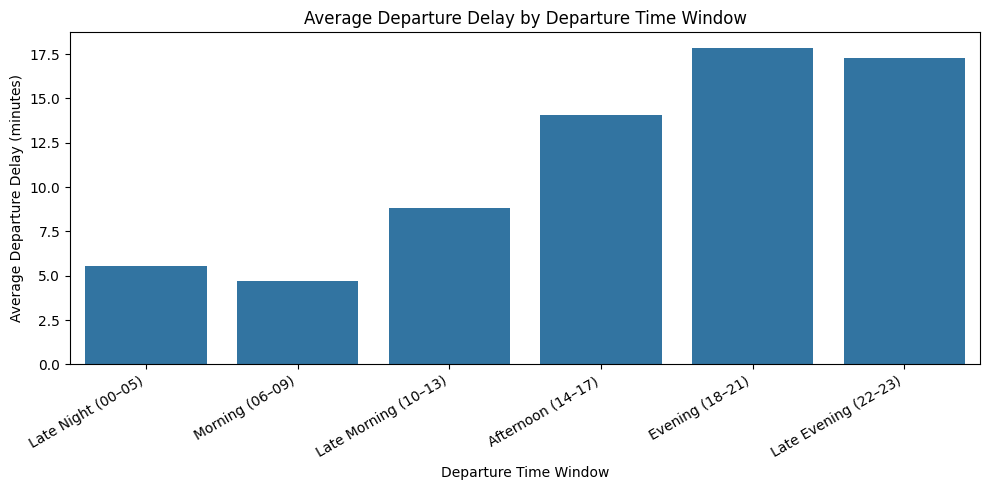

In [185]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=window_delay,
    x="dep_window",
    y="avg_dep_delay"
)
plt.xticks(rotation=30, ha="right")
plt.xlabel("Departure Time Window")
plt.ylabel("Average Departure Delay (minutes)")
plt.title("Average Departure Delay by Departure Time Window")
plt.tight_layout()
plt.show()

#### Conclusion
It's clear that morning flights (6 to 9am) are the best in terms of delays, while afternoon flights are more delay prone.

### Weather Effects on Delays
We'll examine how weather causes delays.  We'll start the exploration with exploring the distribution of delay times throughout the year as well as geographically. 

In [186]:
dep["month"] = dep["FlightDate"].dt.month_name()
dep["month_num"] = dep["FlightDate"].dt.month 

monthly_delay_stats = (
    dep.groupby(["month_num", "month"])["ArrDelay"]
      .agg(
          n_flights="size",
          mean_delay="mean",
          median_delay="median",
          p90_delay=lambda s: s.quantile(0.90),
          total_delay="sum"
      )
      .sort_index()   
)

monthly_delay_stats


,,n_flights,mean_delay,median_delay,p90_delay,total_delay
month_num,month,,,,,
1,January,3132531,3.510834,-8.0,36.0,10654809.0
2,February,2929303,2.508399,-8.0,33.0,7171768.0
3,March,3430518,3.283754,-7.0,35.0,10767970.0
4,April,3048097,4.116857,-7.0,36.0,11846018.0
5,May,3050329,6.286465,-6.0,40.0,18852028.0
6,June,3147108,11.173188,-4.0,54.0,34406010.0
7,July,3399009,12.753994,-4.0,59.0,42285766.0
8,August,2767716,7.148390,-6.0,43.0,19314806.0
9,September,2570852,1.043673,-8.0,26.0,2649204.0


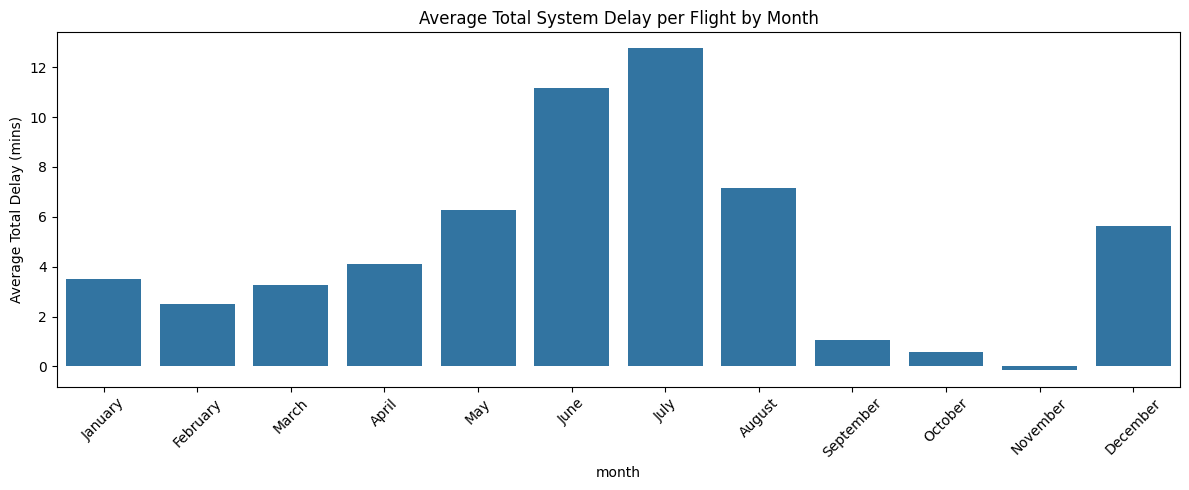

In [187]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=monthly_delay_stats.reset_index(),
    x="month",
    y="mean_delay",
    order=monthly_delay_stats.reset_index()["month"]
)
plt.xticks(rotation=45)
plt.ylabel("Average Total Delay (mins)")
plt.title("Average Departures Delay per Flight by Month")
plt.tight_layout()
plt.show()


In [188]:
#Plotting Flights per month to control for effect of volume on delays
flights_per_month = (
    dep.groupby(["month_num", "month"])
      .size()
      .reset_index(name="n_flights")
      .sort_values("month_num")
)

flights_per_month


,month_num,month,n_flights
0,1,January,3132531
1,2,February,2929303
2,3,March,3430518
3,4,April,3048097
4,5,May,3050329
5,6,June,3147108
6,7,July,3399009
7,8,August,2767716
8,9,September,2570852
9,10,October,2703646


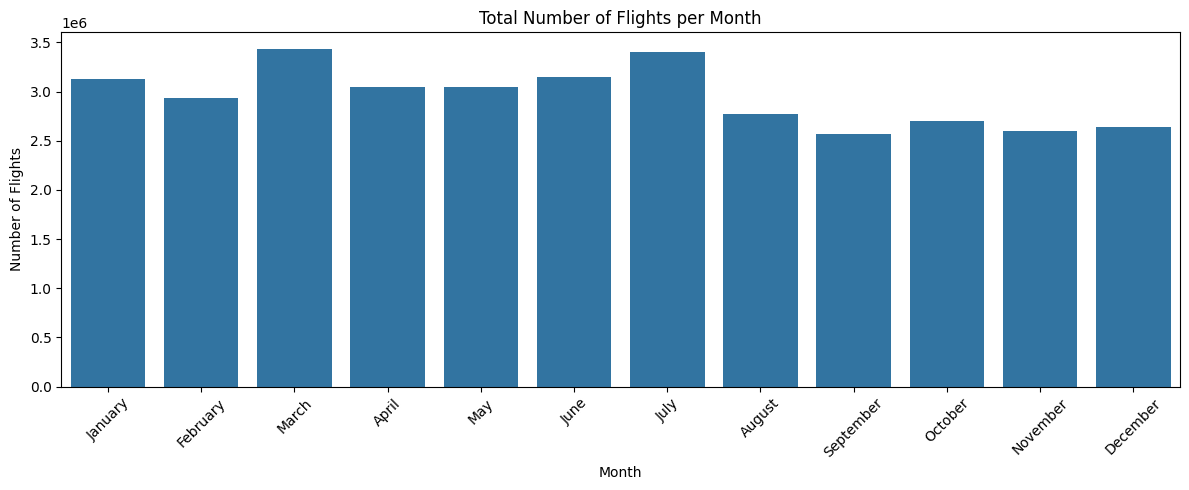

In [189]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=flights_per_month,
    x="month",
    y="n_flights",
    order=flights_per_month["month"]
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.title("Total Number of Flights per Month")
plt.tight_layout()
plt.show()


The relatively uniform distribution of flights tells us we can neglect volume as a factor in monthly delays.  This aligns to our earlier finding that total volume and volume difference contribute very little to delays.

In [192]:
dep

,FlightDate,Reporting_Airline,Tail_Number,Origin,Dest,CRSDepTime,DepDelay,TaxiOut,WheelsOff,WheelsOn,...,Distance,CarrierDelay,WeatherDelay,NASDelay,route,CRSDepDateTime,dep_hour,dep_window,month,month_num
0,2020-01-17,B6,N661JB,PBI,BDL,1940,-14.0,15.0,1941.0,2212.0,...,1133.0,NaN,0.0,NaN,PBI_BDL,2020-01-17 19:40:00,19,Evening (18–21),January,1
1,2020-01-18,B6,N584JB,PBI,BDL,1940,-14.0,14.0,1940.0,2207.0,...,1133.0,NaN,0.0,NaN,PBI_BDL,2020-01-18 19:40:00,19,Evening (18–21),January,1
2,2020-01-19,B6,N662JB,PBI,BDL,1940,7.0,11.0,1958.0,2217.0,...,1133.0,NaN,0.0,NaN,PBI_BDL,2020-01-19 19:40:00,19,Evening (18–21),January,1
3,2020-01-20,B6,N784JB,PBI,BDL,1940,-7.0,27.0,2000.0,2220.0,...,1133.0,NaN,0.0,NaN,PBI_BDL,2020-01-20 19:40:00,19,Evening (18–21),January,1
4,2020-01-21,B6,N784JB,PBI,BDL,1940,12.0,10.0,2002.0,2229.0,...,1133.0,NaN,0.0,NaN,PBI_BDL,2020-01-21 19:40:00,19,Evening (18–21),January,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35417935,2025-07-18,NK,N679NK,EWR,RDU,1559,-7.0,11.0,1603.0,1709.0,...,416.0,NaN,0.0,NaN,EWR_RDU,2025-07-18 15:59:00,15,Afternoon (14–17),July,7
35417936,2025-07-19,NK,N664NK,EWR,RDU,1600,-4.0,63.0,1659.0,1827.0,...,416.0,0.0,0.0,54.0,EWR_RDU,2025-07-19 16:00:00,16,Afternoon (14–17),July,7
35417937,2025-07-20,NK,N664NK,EWR,RDU,1559,-6.0,27.0,1620.0,1742.0,...,416.0,NaN,0.0,NaN,EWR_RDU,2025-07-20 15:59:00,15,Afternoon (14–17),July,7
35417938,2025-07-21,NK,N664NK,EWR,RDU,1559,16.0,14.0,1629.0,1735.0,...,416.0,NaN,0.0,NaN,EWR_RDU,2025-07-21 15:59:00,15,Afternoon (14–17),July,7


In [217]:
#For averaging purposes, count the number of years each month appears in the record
month_year_count_dict = (
    dep.groupby(dep["FlightDate"].dt.month_name())["FlightDate"]
      .apply(lambda s: s.dt.year.nunique())
      .to_dict()
)
month_year_count_df = (
    pd.DataFrame.from_dict(month_year_count, orient="index", columns=["month_count"])
)
month_year_count_df

AttributeError: type object 'Series' has no attribute 'from_dict'

In [225]:
wx_delay_totals_by_month = dep.groupby("month")["WeatherDelay"].sum()
monthly_avg_wx_delay = wx_delay_totals_by_month / month_year_count_df["month_count"]
monthly_avg_wx_delay
monthly_avg_wx_delay_df = monthly_avg_wx_delay.reset_index()
monthly_avg_wx_delay_df.columns = ["month", "avg_minutes"]

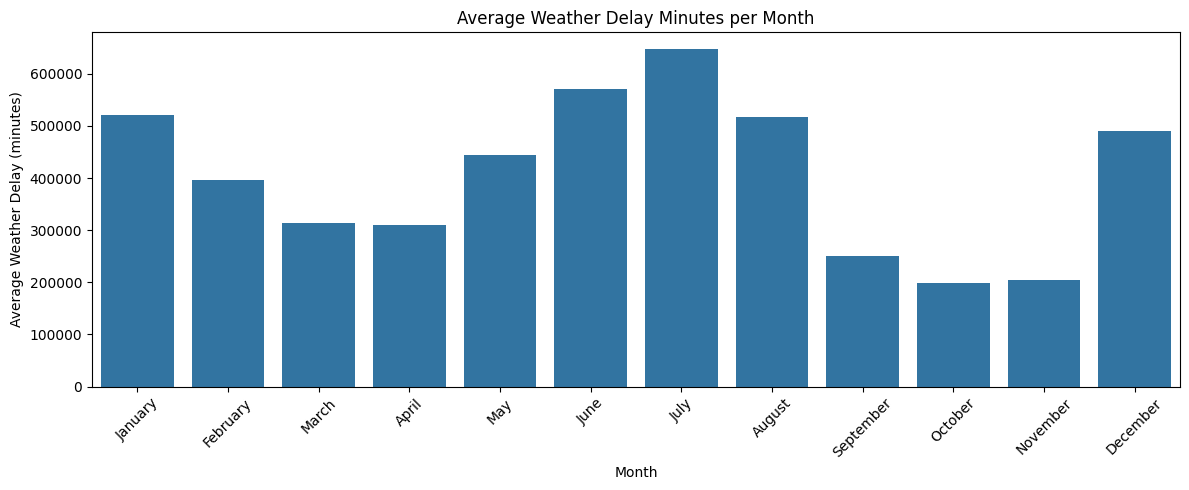

In [226]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=monthly_avg_wx_delay_df,
    x="month",
    y="avg_minutes",
    order=wx_by_month["month"]
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Average Weather Delay (minutes)")
plt.title("Average Weather Delay Minutes per Month")
plt.tight_layout()
plt.show()


It's apparent the average weather delay per month follows a similar pattern to avereage dealy per flight per month.  Now, we'll examine the percentage of flights with any delay that also had a weather delay on a monthly basis.

In [230]:
#Create a binary column that indicates whether a delay of any type occurred.
#Logic is if either arrival or departure delay is positive, set to 1, otherwise 0
dep["AnyDelay"] = ((dep["DepDelay"] > 0) | (dep["ArrDelay"] > 0)).astype(int)
dep["AnyDelay"]

0           0
1           0
2           1
3           1
4           1
           ..
35417935    0
35417936    1
35417937    1
35417938    1
35417939    0
Name: AnyDelay, Length: 35417938, dtype: int64

In [232]:
monthly_weather_pct = (
    dep.groupby(["month_num", "month"])
      .apply(lambda g: (
          ((g["AnyDelay"] == 1) & (g["WeatherDelay"] > 0)).sum() /
          (g["AnyDelay"] == 1).sum()
      ))
      .reset_index(name="pct_anydelay_with_weather")
      .sort_values("month_num")
)

monthly_weather_pct["pct_anydelay_with_weather"] *= 100
monthly_weather_pct


C:\Users\brandon.chambers\AppData\Local\Temp\ipykernel_27820\2369183912.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (


,month_num,month,pct_anydelay_with_weather
0,1,January,3.069898
1,2,February,2.649380
2,3,March,1.978304
3,4,April,2.236302
4,5,May,2.901428
5,6,June,3.352853
6,7,July,3.605963
7,8,August,3.181222
8,9,September,2.016682
9,10,October,1.308443


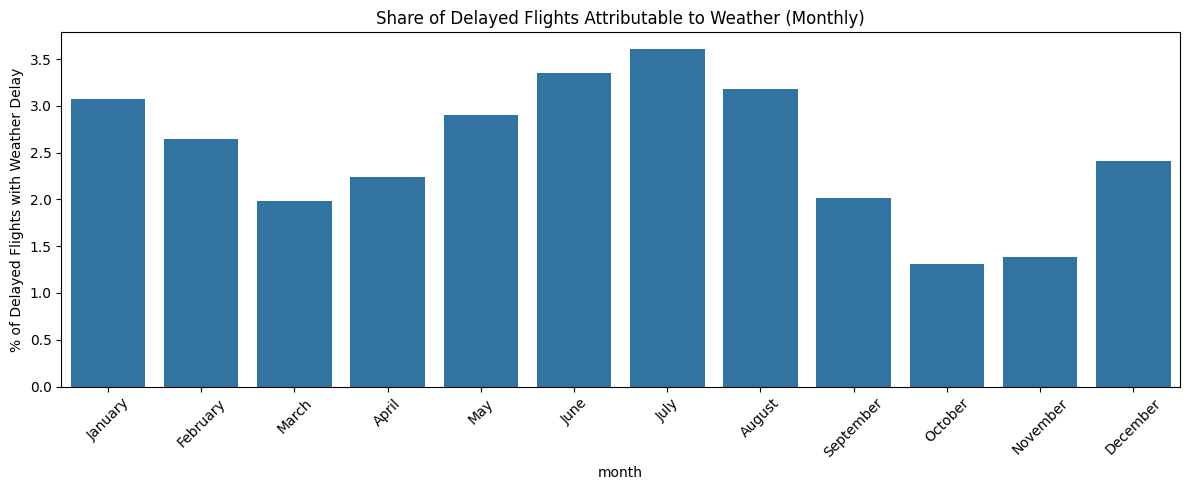

In [233]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=monthly_weather_pct,
    x="month",
    y="pct_anydelay_with_weather",
    order=monthly_weather_pct["month"]
)

plt.xticks(rotation=45)
plt.ylabel("% of Delayed Flights with Weather Delay")
plt.title("Share of Delayed Flights Attributable to Weather (Monthly)")
plt.tight_layout()
plt.show()


It's clear the weather shares a similar pattern to the overall delays by month, but the low percentages indicate weather isn't generally a major contributor to overall delays. To get a sense of where weather is most likely to be an issue, let's examine the weather delays at the top 100 airports by volume.

In [236]:
#Create a dataframe of airports with total volume
airport_volume = (
    df.melt(
        id_vars=["FlightDate"],
        value_vars=["Origin", "Dest"],
        var_name="role",
        value_name="airport"
    )
    .groupby("airport")
    .size()
    .reset_index(name="flight_volume")
)
airport_volume

,airport,flight_volume
0,ABE,45816
1,ABI,20333
2,ABQ,229967
3,ABR,8091
4,ABY,9877
...,...,...
379,XNA,119481
380,XWA,16457
381,YAK,8088
382,YKM,2733


In [237]:
top100_airports = (
    airport_volume
    .sort_values("flight_volume", ascending=False)
    .head(100)["airport"]
    .tolist()
)


In [238]:
df["WeatherDelay"] = df["WeatherDelay"].fillna(0)

airport_weather = (
    df.melt(
        id_vars=["WeatherDelay"],
        value_vars=["Origin", "Dest"],
        var_name="role",
        value_name="airport"
    )
    .query("airport in @top100_airports")   # keep only top 100
    .groupby("airport")["WeatherDelay"]
    .sum()
    .reset_index(name="total_weather_delay")
    .sort_values("total_weather_delay", ascending=False)
)


In [244]:
#Normalize by volume


top100_volume = airport_volume[airport_volume["airport"].isin(top100_airports)]

airport_weather_rate = (
    airport_weather
    .merge(top100_volume, on="airport", how="left")
)

#minnutes per flight
airport_weather_rate["minutes_per_flight"] = (
    airport_weather_rate["total_weather_delay"] /
    airport_weather_rate["flight_volume"]
)

#sort to improve the plot
airport_weather_rate = airport_weather_rate.sort_values(
    "minutes_per_flight",
    ascending=False
)



C:\Users\brandon.chambers\AppData\Local\Temp\ipykernel_27820\2629937282.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


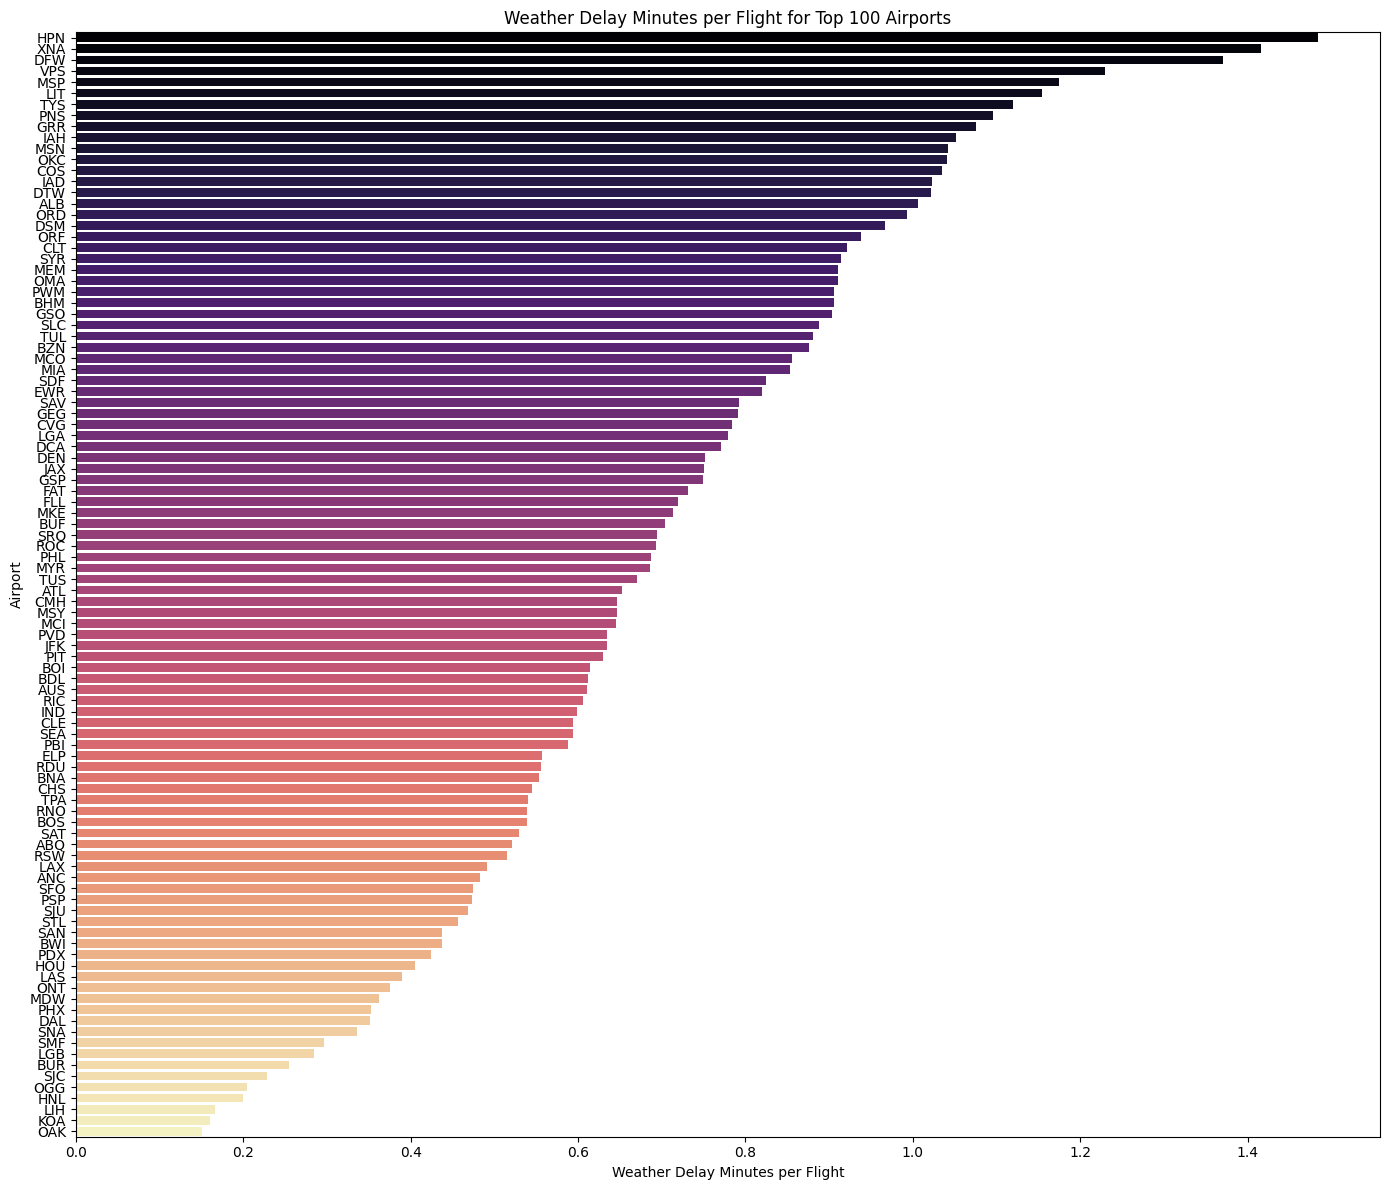

In [245]:
plt.figure(figsize=(14,12))

sns.barplot(
    data=airport_weather_rate,
    y="airport",
    x="minutes_per_flight",
    palette="magma"
)

plt.title("Weather Delay Minutes per Flight for Top 100 Airports")
plt.xlabel("Weather Delay Minutes per Flight")
plt.ylabel("Airport")
plt.tight_layout()
plt.show()




In [246]:
airport_weather_rate.head()

,airport,total_weather_delay,flight_volume,minutes_per_flight
55,HPN,161611.0,108904,1.483977
52,XNA,169149.0,119481,1.415698
0,DFW,4293714.0,3133689,1.370179
70,VPS,130929.0,106474,1.229680
5,MSP,1541475.0,1312116,1.174801


Note the 3 of the top 5 airports for weather delay rate are small regional airports with high volumes.  This indicates that the smaller airports are less equipped to deal with weather impacts and slightly more prone to weather delays. 

#### Weather Delay Conclusions
Based on our analysis, it appears weather delays are overall a minor contributor to the probability of flight delay. There are seasonal variations, but, generally, making flight decisions based on weather factors is not advised, especially if flying through major hubs. 
